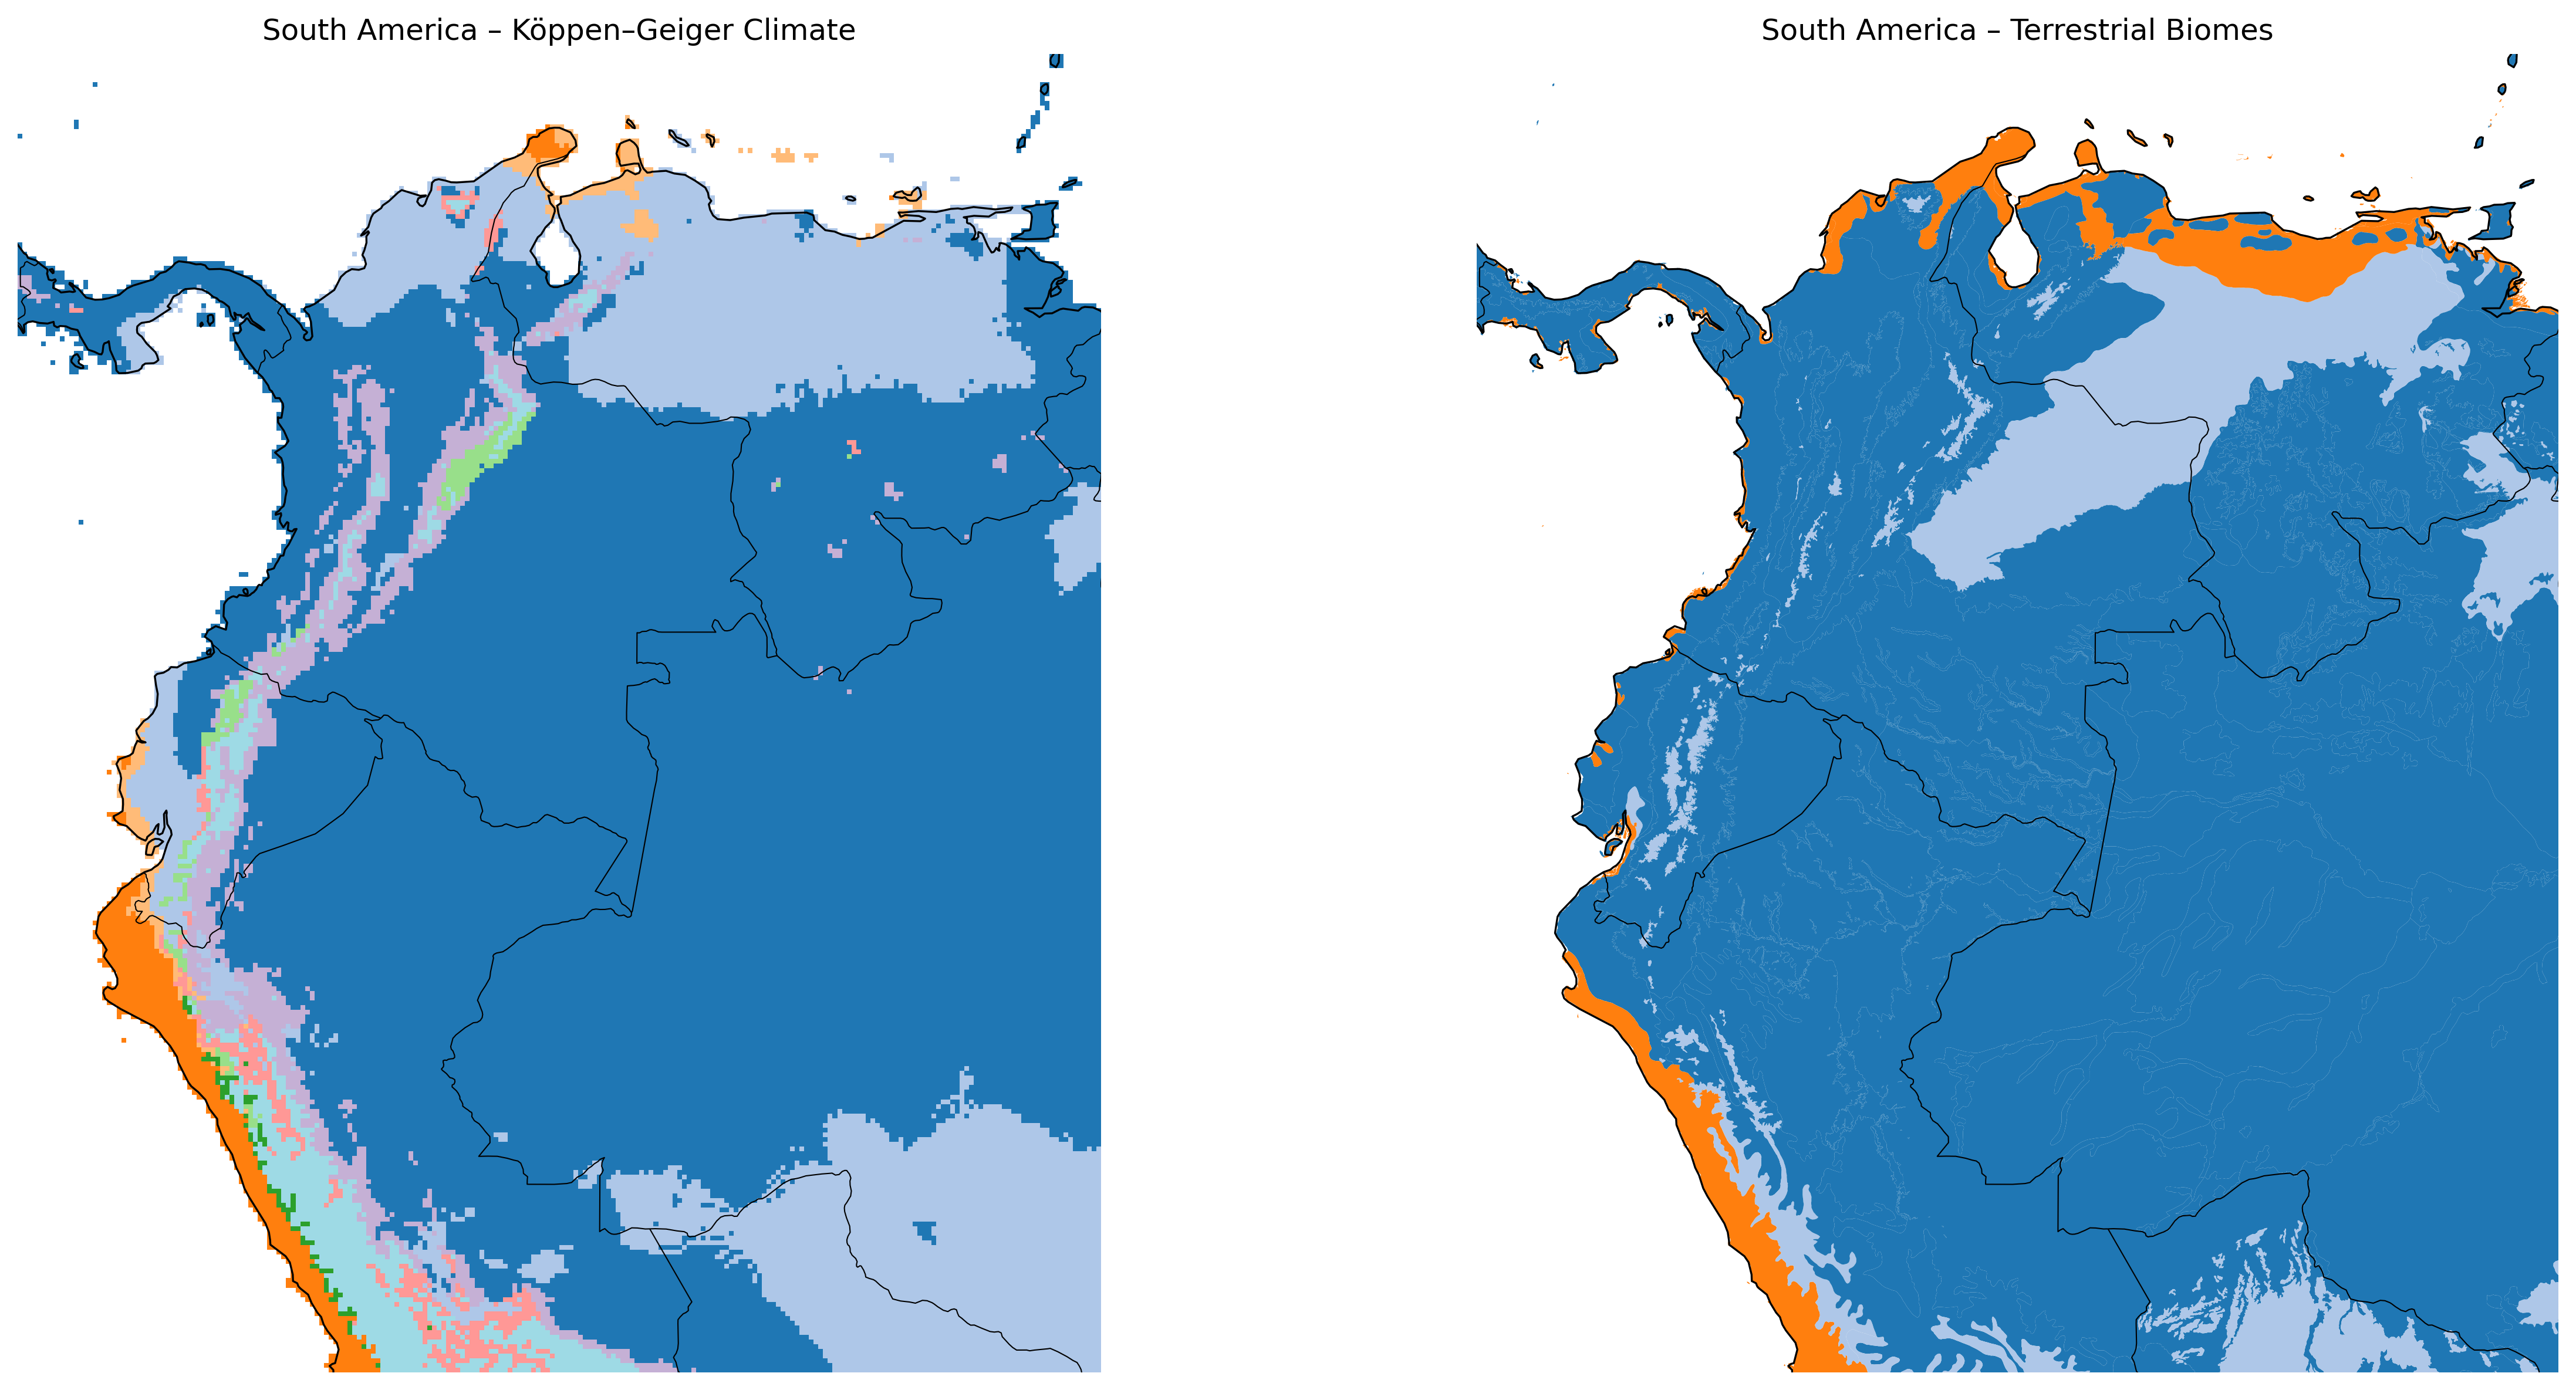

In [2]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# USER-DEFINED MAP EXTENT (lon_min, lon_max, lat_min, lat_max)
# --------------------------------------------------
extent = [-83, -60, -14, 14]

# --------------------------------------------------
# FILE PATHS
# --------------------------------------------------
climate_tif = "data/koppen_geiger_0p1.tif"   # Köppen–Geiger raster
biomes_shp  = "data/biomes/wwf_terr_ecos.shp"

# --------------------------------------------------
# LOAD CLIMATE RASTER
# --------------------------------------------------
with rasterio.open(climate_tif) as src:
    climate = src.read(1)
    climate_extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]
    nodata = src.nodata

climate = np.ma.masked_equal(climate, nodata)

biomes = gpd.read_file(biomes_shp)
if biomes.crs.to_string() != "EPSG:4326":
    biomes = biomes.to_crs(epsg=4326)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(18, 8),
    dpi=300,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Climate map
ax = axes[0]
ax.set_extent(extent)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.imshow(
    climate,
    extent=climate_extent,
    transform=ccrs.PlateCarree(),
    cmap="tab20",
    interpolation="nearest"
)
ax.set_title("South America – Köppen–Geiger Climate")

# Biome map
ax = axes[1]
ax.set_extent(extent)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

biomes.plot(
    ax=ax,
    column="BIOME",
    cmap="tab20",
    linewidth=0,
    transform=ccrs.PlateCarree()
)
ax.set_title("South America – Terrestrial Biomes")

# Optional: hide frames
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('figures/Climates_Northern_South_America.pdf')
plt.show()


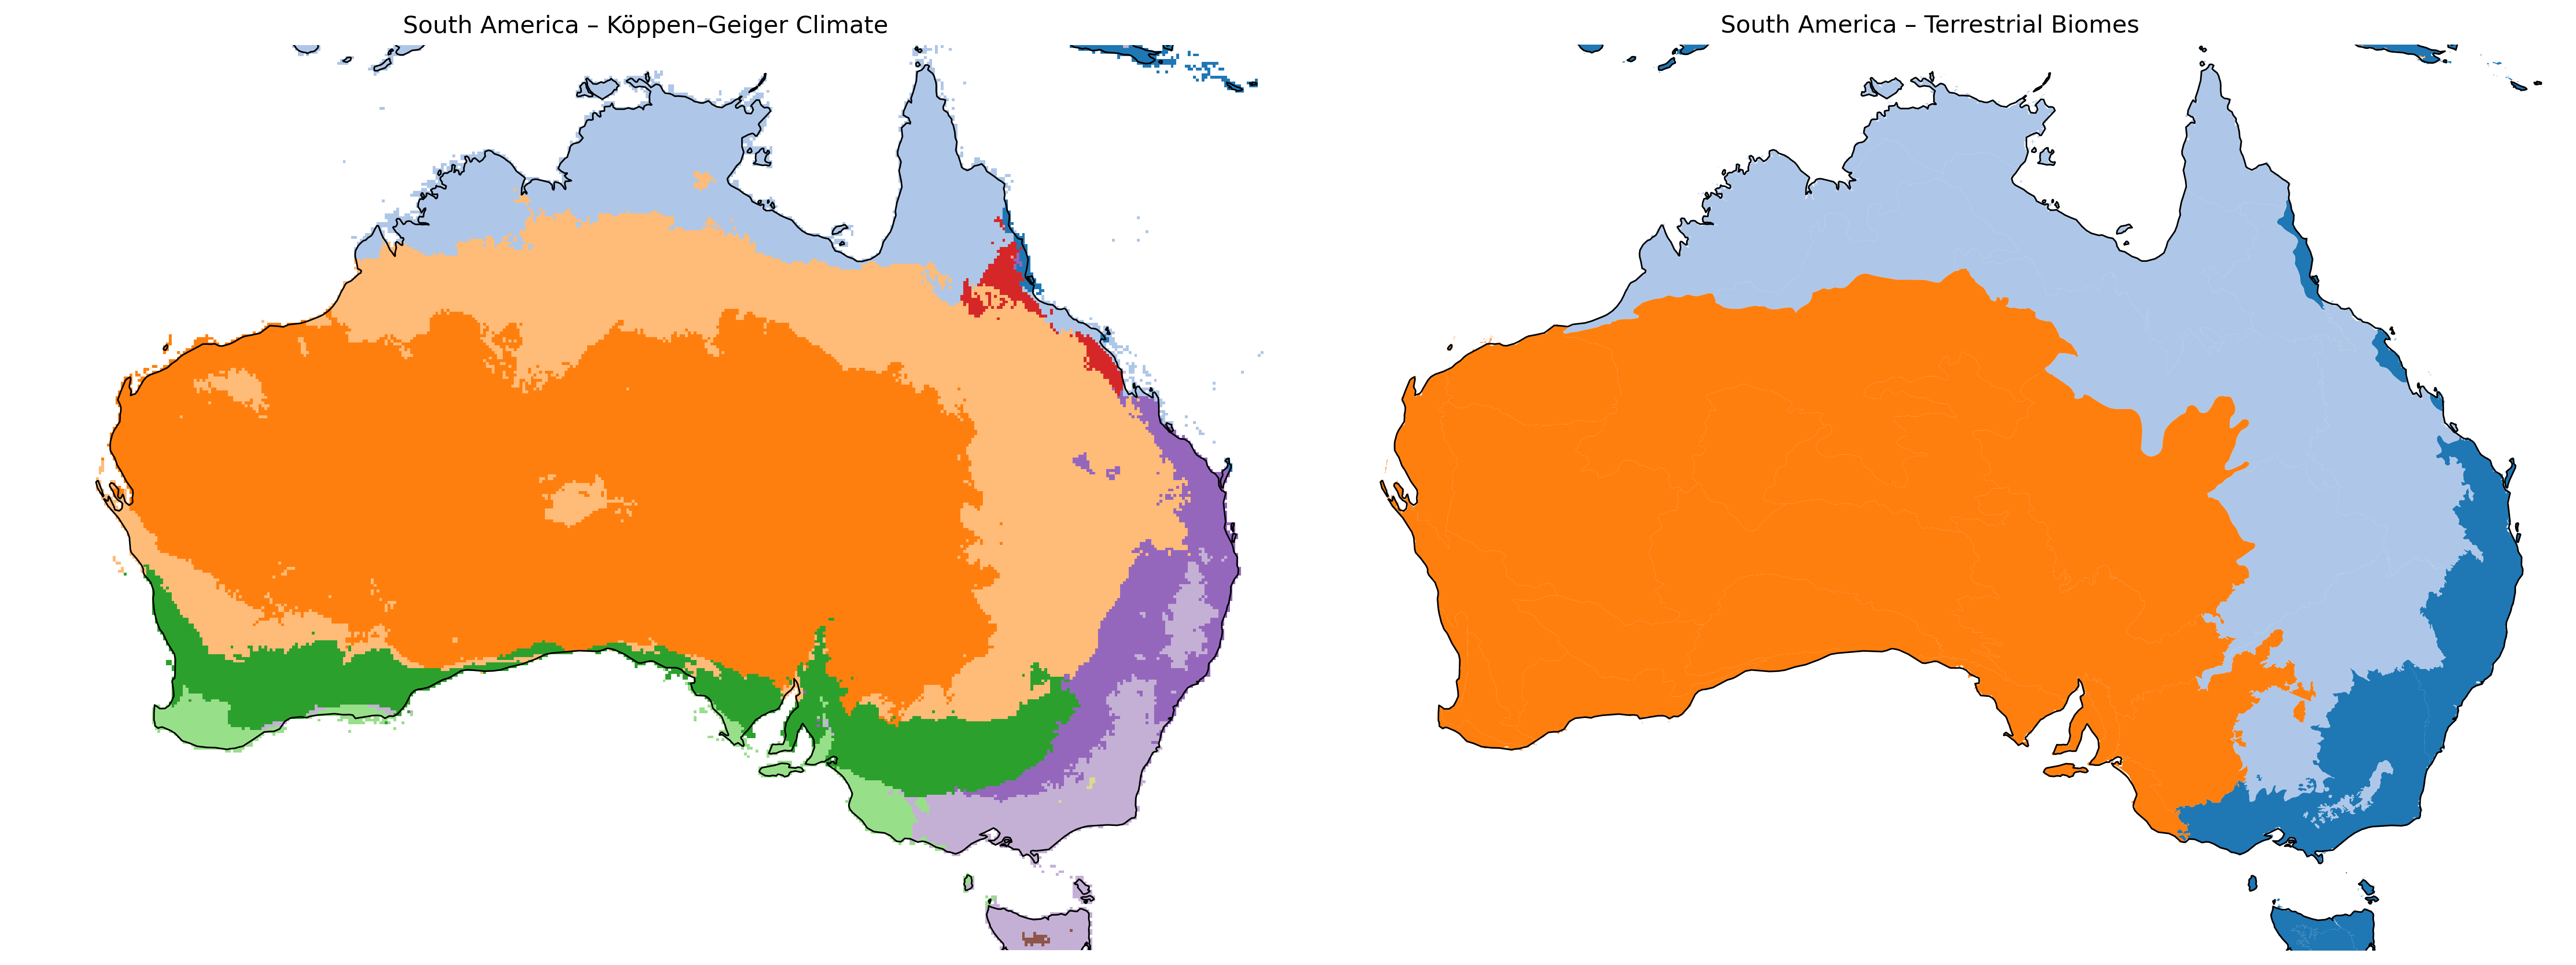

In [1]:
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# USER-DEFINED MAP EXTENT (lon_min, lon_max, lat_min, lat_max)
# --------------------------------------------------
extent = [110, 155, -10, -40]

# --------------------------------------------------
# FILE PATHS
# --------------------------------------------------
climate_tif = "data/koppen_geiger_0p1.tif"   # Köppen–Geiger raster
biomes_shp  = "data/biomes/wwf_terr_ecos.shp"

# --------------------------------------------------
# LOAD CLIMATE RASTER
# --------------------------------------------------
with rasterio.open(climate_tif) as src:
    climate = src.read(1)
    climate_extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]
    nodata = src.nodata

climate = np.ma.masked_equal(climate, nodata)

biomes = gpd.read_file(biomes_shp)
if biomes.crs.to_string() != "EPSG:4326":
    biomes = biomes.to_crs(epsg=4326)

fig, axes = plt.subplots(
    ncols=2,
    figsize=(18, 8),
    dpi=300,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Climate map
ax = axes[0]
ax.set_extent(extent)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.imshow(
    climate,
    extent=climate_extent,
    transform=ccrs.PlateCarree(),
    cmap="tab20",
    interpolation="nearest"
)
ax.set_title("South America – Köppen–Geiger Climate")

# Biome map
ax = axes[1]
ax.set_extent(extent)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

biomes.plot(
    ax=ax,
    column="BIOME",
    cmap="tab20",
    linewidth=0,
    transform=ccrs.PlateCarree()
)
ax.set_title("South America – Terrestrial Biomes")

# Optional: hide frames
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('figures/Climates_Australia.pdf')
plt.show()
